In [15]:
import time
import requests
import pandas as pd
from pathlib import Path

In [ ]:
PIXSCALE = 0.262        # escala de / pixel
SIZE     = 800          # píxeles de lado
LAYER    = 'ls-dr10'
BANDS    = 'grz'        # un solo FITS con las 3 bandas — shape (3, SIZE, SIZE)
DELAY_S  = 0.5          # pausa entre requests

CSV_PATH  = Path('catalogs/clasification/classification_dataset.csv')
DATA_DIR  = Path('data')

CLASS_DIRS = {
    0: DATA_DIR / 'no_ring',
    1: DATA_DIR / 'ring_internal',
}
for d in CLASS_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print('Carpetas listas:')
for d in CLASS_DIRS.values():
    print(f'  {d}')

Carpetas listas:
  data/no_ring
  data/ring_internal


In [17]:
df = pd.read_csv(CSV_PATH)
print(f'Total galaxias: {len(df)}')
print(df['label'].value_counts().rename({0: 'Sin anillo (0)', 1: 'Anillo interno (1)'}))
df.head()

Total galaxias: 8408
label
Sin anillo (0)        6660
Anillo interno (1)    1748
Name: count, dtype: int64


,name,objra,objdec,nsa_z,anillos,source,label
0,1237648721210769659,134.44717,-0.199973,0.028206,0,sdss,0
1,1237648705657307354,198.23356,0.941188,0.048037,0,sdss,0
2,1237648705120895059,199.29492,0.527571,0.024114,0,sdss,0
3,1237648720150724863,165.74061,-0.962095,0.033483,0,sdss,0
4,1237649919509594232,31.37202,13.251016,0.024694,0,sdss,0


In [18]:
BASE_URL = 'http://legacysurvey.org/viewer/fits-cutout'

def build_url(ra: float, dec: float) -> str:
    return (
        f'{BASE_URL}?ra={ra:.6f}&dec={dec:.6f}'
        f'&size={SIZE}&layer={LAYER}&pixscale={PIXSCALE}&bands={BANDS}'
    )

def safe_name(name: str) -> str:
    return name.replace('/', '_').replace(' ', '_').replace(':', '_')

def download_fits(ra: float, dec: float, out_path: Path) -> bool:
    """Descarga un FITS multi-banda (grz). Retorna True si fue exitoso."""
    if out_path.exists():
        print(f'  [skip] {out_path.name}')
        return True

    url = build_url(ra, dec)
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()

        if resp.content[:6] != b'SIMPLE':
            print(f'  [warn] Respuesta inesperada: {resp.content[:40]}')
            return False

        out_path.write_bytes(resp.content)
        print(f'  [ok]  {out_path.name}  ({len(resp.content) / 1024:.0f} KB)')
        return True

    except requests.RequestException as e:
        print(f'  [err] {out_path.name}: {e}')
        return False

In [ ]:
# Cambia o modificar el numero de la variable `N_TEST = 3 para descargar solo un subconjunto de galaxias para prueba
N_TEST = None

subset  = df.head(N_TEST) if N_TEST else df
results = []

for _, row in subset.iterrows():
    name    = safe_name(str(row['name']))
    ra      = float(row['objra'])
    dec     = float(row['objdec'])
    label   = int(row['label'])
    out_dir = CLASS_DIRS[label]

    print(f'\n{name}  ra={ra:.4f}  dec={dec:.4f}  label={label}')
    out_path = out_dir / f'{name}_grz.fits'
    ok = download_fits(ra, dec, out_path)
    results.append({'name': name, 'label': label, 'ok': ok, 'path': str(out_path)})
    time.sleep(DELAY_S)

results_df = pd.DataFrame(results)
print('\n--- Resumen ---')
print(results_df['ok'].value_counts().rename({True: 'Exitosas', False: 'Fallidas'}))


1237648721210769659  ra=134.4472  dec=-0.2000  label=0
  [skip] 1237648721210769659_grz.fits

1237648705657307354  ra=198.2336  dec=0.9412  label=0
  [skip] 1237648705657307354_grz.fits

1237648705120895059  ra=199.2949  dec=0.5276  label=0
  [skip] 1237648705120895059_grz.fits

--- Resumen ---
ok
Exitosas    3
Name: count, dtype: int64


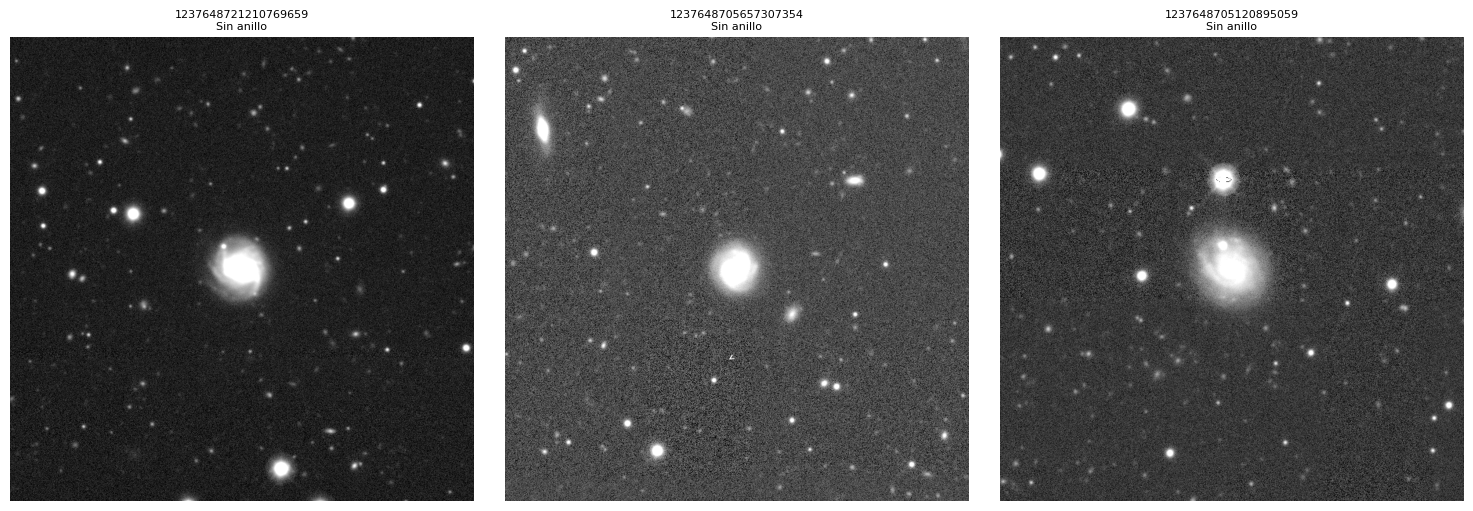

In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

def asinh_stretch(data, lo=0.5, hi=99.5):
    vmin, vmax = np.percentile(data[np.isfinite(data)], [lo, hi])
    norm = np.clip((data - vmin) / (vmax - vmin + 1e-10), 0, 1)
    return np.arcsinh(10 * norm) / np.arcsinh(10)

ok_rows = results_df[results_df['ok']]
n = len(ok_rows)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, ok_rows.iterrows()):
    with fits.open(row['path']) as hdul:
        img = hdul[0].data.mean(axis=0)  # promedio de las 3 bandas
    ax.imshow(asinh_stretch(img), origin='lower', cmap='gray')
    label_str = 'Sin anillo' if row['label'] == 0 else 'Anillo interno'
    ax.set_title(f"{row['name']}\n{label_str}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()